In [41]:
!pip install Levenshtein

In [42]:
import xml.etree.ElementTree as ET
import pprint
import pandas as pd
import seaborn as sns
import json
import pandas as pd
from scipy.stats import randint
import torch
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
from torch.utils.data import Dataset, DataLoader
import math
import copy

from sklearn.model_selection import train_test_split
 
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import Levenshtein

## Парсинг XML-файла

In [43]:
def parse_word(word_el):
    word_dict = {}
    word_dict['original'] = word_el.attrib.get('original', '')

    if 'nucleus' in word_el.attrib:
        word_dict['nucleus'] = int(word_el.attrib['nucleus'])

    # letters
    letters = []
    for letter in word_el.findall('letter'):
        letters.append({
            'char': letter.attrib.get('char', ''),
            'flag': int(letter.attrib.get('flag', 0)),
            'allophone': None
        })
    word_dict['letters'] = letters

    # allophones
    allophones = [a.attrib['ph'] for a in word_el.findall('allophone')]
    word_dict['allophones'] = allophones

    # dictitem
    dictitem_el = word_el.find('dictitem')
    if dictitem_el is not None:
        dictitem = {k: int(v) if v.isdigit() else v for k, v in dictitem_el.attrib.items()}
        word_dict['dictitem'] = dictitem

    return word_dict


def parse_sentence(sentence_el):
    syntagmas = []
    buffer_words = []
    punkt_end = None
    intonation = None
    pause = None

    elements = list(sentence_el)
    for elem in elements:
        if elem.tag == 'word':
            buffer_words.append(parse_word(elem))

        elif elem.tag == 'content' and 'PunktEnd' in elem.attrib:
            # сохраняем пунктуацию, но не завершаем синтагму
            punkt_end = int(elem.attrib['PunktEnd'])

        elif elem.tag == 'intonation':
            intonation = int(elem.attrib.get('type', 0))

        elif elem.tag == 'pause':
            pause = {
                'type': elem.attrib.get('type'),
                'time': int(elem.attrib.get('time', 0))
            }

            # конец синтагмы: собираем всё вместе
            syntagmas.append({
                'words': buffer_words,
                'punkt_end': punkt_end,
                'intonation': intonation,
                'pause': pause
            })

            # сброс для новой синтагмы
            buffer_words = []
            punkt_end = None
            intonation = None
            pause = None

    return syntagmas


def parse_xml(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()
    all_sentences = []
    for sentence_el in root.findall('.//sentence'):
        syntagmas = parse_sentence(sentence_el)
        all_sentences.append(syntagmas)
    return all_sentences


In [44]:
path = r'/kaggle/input/bunin-xml/bunin_i_a-text_2622.Result.xml'

In [45]:
try:
    data = parse_xml(path)
except ET.ParseError as e:
    print(f"XML Parse Error: {e}")
    print("Please check the XML file for structural issues.")
    data = None # Set data to None or handle the error as appropriate for your workflow

In [46]:
# пример разметки
pprint.pprint(data[0])

[{'intonation': 11,
  'pause': {'time': 1376, 'type': 'x-long'},
  'punkt_end': 1,
  'words': [{'allophones': ["t'", 'o0', 'm', 'n', 'y4', 'j', 'i4'],
             'dictitem': {'form': 39,
                          'genesys': 0,
                          'stress_dict': 1,
                          'subpart_of_speech': 3,
                          'yo_place1': 1},
             'letters': [{'allophone': None, 'char': 'т', 'flag': 16},
                         {'allophone': None, 'char': 'ё', 'flag': 25},
                         {'allophone': None, 'char': 'м', 'flag': 16},
                         {'allophone': None, 'char': 'н', 'flag': 16},
                         {'allophone': None, 'char': 'ы', 'flag': 24},
                         {'allophone': None, 'char': 'е', 'flag': 24}],
             'original': 'ТЕМНЫЕ'},
            {'allophones': ['a1', "l'", 'e0', 'i4'],
             'dictitem': {'form': 9,
                          'genesys': 5,
                          'stress_dict': 

## Получение признаков

In [47]:
def get_features(data):
    vowels = set('аеёиоуыэюяАЕЁИОУЫЭЮЯ')  # набор гласных (для русского языка)

    def count_vowels(word):
        """Подсчет количества гласных в слове"""
        return sum(1 for ch in word if ch in vowels)

    rows = []
    synt_num = 0

    for sent in data:
        total_sent_len = sum(
            len([w for w in synt['words'] if w['dictitem'].get('stress_dict')])
            for synt in sent
        ) # считаем общее число фонетических слов в предложении
        sent_len = 0 # сколько фонетических слов мы уже прошли в предложении

        for j, synt in enumerate(sent):
            # Интонацию, паузы и пунктуацию получаем для каждой синтагмы
            synt_num += 1
            intonation = synt['intonation']

            if synt['pause'] is not None:
                synt_pause_len = synt['pause']['time']
                synt_pause_type = synt['pause']['type']
            else:
                synt_pause_len = None
                synt_pause_type = None

            punctuation = synt['punkt_end']

            synt_words = [w['original'] for w in synt['words'] if w['original'] != '']
            synt_len = len([w for w in synt['words'] if w['dictitem'].get('stress_dict')])
            count_phon_words = 0

            for i, word in enumerate(synt['words']):
                allophones = word.get('allophones', [])
                if word['dictitem'].get('stress_dict'):
                    count_phon_words += 1
                    words_before = count_phon_words - 1
                    words_after = synt_len - count_phon_words
                    word_index = count_phon_words

                    sent_words_before = sent_len + words_before
                    sent_words_after = total_sent_len - (sent_words_before + 1)

                    if words_after != 0: # Длительность паузы будем указывать только для последнего слова в синтагме
                        pause_len = 0
                        pause_type = 0
                    else:
                        pause_len = synt_pause_len
                        pause_type = synt_pause_type
                else: # Для слов, на которых нет ударения, будем указываь информацию такую же, как для слова за ним
                    words_before = count_phon_words
                    words_after = synt_len - (count_phon_words + 1)
                    word_index = count_phon_words + 1
                    pause_len = 0
                    pause_type = 0
                    sent_words_before = sent_len + words_before
                    sent_words_after = total_sent_len - (sent_words_before + 1)

                w = word['original']
                if w != '':
                    word_length = len(w)
                    part_of_speech = word['dictitem']['subpart_of_speech']
                    word_form = word['dictitem']['form']
                    word_genesys = word['dictitem']['genesys']
                    word_semantics1 = word['dictitem'].get('semantics1')
                    word_semantics2 = word['dictitem'].get('semantics2')

                    if i >= synt_len - 1:
                        next_word = None
                    elif i < synt_len - 2 and synt['words'][i + 1]['original'] == '':
                        next_word = synt['words'][i + 2]['original'] if i < synt_len - 1 else None
                    else:
                        next_word = synt['words'][i + 1]['original'] if i < synt_len - 1 else None

                    previous_word = synt['words'][i - 1]['original'] if i > 0 else None
                    capital_letter = 1 if w[0].isupper() else 0
                    nucleus = word.get('nucleus', 0)
                else:
                    word_length = len(synt['words'][i - 1]['original'])
                    part_of_speech = word['dictitem']['subpart_of_speech']
                    word_form = word['dictitem']['form']
                    word_genesys = word['dictitem']['genesys']
                    word_semantics1 = word['dictitem'].get('semantics1')
                    word_semantics2 = word['dictitem'].get('semantics2')

                    previous_word = synt['words'][i - 2]['original'] if i > 0 else None
                    next_word = synt['words'][i + 1]['original'] if i < synt_len - 1 else None
                    capital_letter = 0
                    nucleus = word.get('nucleus', 0)

                # --- Новое: подсчёт гласных ---
                vowels_in_word = count_vowels(w)

                # гласные во всех словах ДО текущего в синтагме
                vowels_before = sum(count_vowels(sw) for sw in synt_words[:i])
                # гласные во всех словах ПОСЛЕ текущего в синтагме
                vowels_after = sum(count_vowels(sw) for sw in synt_words[i + 1:])

                # добавляем в rows
                rows.append({
                    'word': w, #[letter for letter in w],
                    #'synt_num': synt_num,
                    'word_length': word_length,
                    'part_of_speech': part_of_speech,
                    'word_form': word_form,
                    #'word_genesys': word_genesys,
                    #'word_semantics1': word_semantics1,
                    #'word_semantics2': word_semantics2,
                    #'word_index': word_index,
                    'words_before': words_before,
                    #'words_after': words_after,
                    #'sent_words_before': sent_words_before,
                    #'sent_words_after': sent_words_after,
                    #'vowels_in_word': vowels_in_word,
                    #'vowels_before': vowels_before,
                    #'vowels_after': vowels_after,
                    'previous_word': previous_word,
                    'next_word': next_word,
                    #'capital_letter': capital_letter,
                    #'nucleus': nucleus,
                    #'intonation': intonation,
                    #'pause_len': pause_len,
                    #'pause_type': pause_type,
                    'punctuation': punctuation,
                    'allophones': allophones
                })

            sent_len += synt_len
    return rows


In [48]:
df = pd.DataFrame(get_features(data))
df.head()

,word,word_length,part_of_speech,word_form,words_before,previous_word,next_word,punctuation,allophones
0,ТЕМНЫЕ,6,3,39,0,None,АЛЛЕИ,1.0,"[t', o0, m, n, y4, j, i4]"
1,АЛЛЕИ,5,2,9,1,ТЕМНЫЕ,None,1.0,"[a1, l', e0, i4]"
2,В,1,9,0,0,None,холодное,2.0,[f]
3,холодное,8,3,36,0,В,осеннее,2.0,"[h, a1, l, o0, d, n, a4, j, i4]"
4,осеннее,7,3,36,1,холодное,None,2.0,"[a1, s', e0, n', i4, j, i4]"


In [49]:
(len(df)/23)*0.3

460.2652173913043

In [50]:
# Проверка на наличие пропусков
nan_cols = df.isna().any()
nan_cols

word              False
word_length       False
part_of_speech    False
word_form         False
words_before      False
previous_word      True
next_word          True
punctuation        True
allophones        False
dtype: bool

In [51]:
df = df.fillna('-')

## Датасет

In [52]:
class PhoneTokenizer:
    def __init__(self, sequences):

        # уникальные аллофоны
        unique_phones = sorted(set(phone for seq in sequences for phone in seq))
        self.phone2id = {p: i+2 for i, p in enumerate(unique_phones)}  # +2 для PAD=0, BOS=1
        self.phone2id["<PAD>"] = 0
        self.phone2id["<BOS>"] = 1
        self.phone2id["<EOS>"] = len(self.phone2id)

        self.id2phone = {v: k for k, v in self.phone2id.items()}

    def encode(self, seq, add_special_tokens=True, max_length=50):
        ids = [self.phone2id.get(p, 0) for p in seq]  # 0 = PAD/UNK
        if add_special_tokens:
            ids = [self.phone2id["<BOS>"]] + ids + [self.phone2id["<EOS>"]]
        # паддинг до max_length
        if len(ids) < max_length:
            ids += [self.phone2id["<PAD>"]] * (max_length - len(ids))
        return ids[:max_length]

    def decode(self, ids):
        phones = []
        for i in ids:
            if i in (0, 1):  # PAD или BOS
                continue
            if self.id2phone[i] == "<EOS>":
                break
            phones.append(self.id2phone[i])
        return phones


In [53]:
class CharTokenizer:
    def __init__(self, texts):
        chars = sorted(set("".join(texts)))
        self.char2id = {c: i+4 for i, c in enumerate(chars)}  # +2 для PAD/BOS
        self.char2id["<PAD>"] = 0
        self.char2id["<BOS>"] = 1
        self.char2id["="] = 2
        self.char2id["|"] = 3
        self.char2id["<EOS>"] = len(self.char2id)
        self.id2char = {v: k for k, v in self.char2id.items()}

    def encode(self, text, add_special_tokens=True, max_length=50):
        ids = [self.char2id.get(c, 0) for c in text]
        if add_special_tokens:
            ids = [self.char2id["<BOS>"]] + ids + [self.char2id["<EOS>"]]
        if len(ids) < max_length:
            ids += [self.char2id["<PAD>"]] * (max_length - len(ids))
        return ids[:max_length]

    def decode(self, ids):
        return "".join(self.id2char[i] for i in ids if i not in (0,1,self.char2id["<EOS>"]))



In [54]:

class CustomDataset(Dataset):
    def __init__(self, dataframe, input_tokenizer, target_tokenizer, max_len=50):
        self.df = dataframe
        self.input_tokenizer = input_tokenizer
        self.target_tokenizer = target_tokenizer
        self.max_len = max_len

    def __getitem__(self, idx):
        row = self.df.iloc[idx]

        # вход — строка
        src_ids = torch.tensor(self.input_tokenizer.encode(
            f"{row['word']} | prev={row['previous_word']} | next={row['next_word']}",
            max_length=self.max_len
        ))

        # выход — список аллофонов
        tgt_ids = torch.tensor(self.target_tokenizer.encode(
            row['allophones'], max_length=self.max_len
        ))

        return {"src": src_ids, "tgt": tgt_ids}

    def __len__(self):
        return len(self.df)


In [55]:
m=0
n=0
for i in range(len(df)):

    input = f"prev={df['previous_word'][i]}|word={df['word'][i]}|next={df['next_word'][i]}"
    if len(input)>m:
      m=len(input)
    if len(df['allophones'][i])>n:
      n=len(df['allophones'][i])
print(m, n)

56 18


## Архитектура транформера

In [56]:
class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads):
        super(MultiHeadAttention, self).__init__()
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"

        self.d_model = d_model
        self.num_heads = num_heads
        self.d_k = d_model // num_heads

        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)

    def scaled_dot_product_attention(self, Q, K, V, mask=None):
        attn_scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)
        if mask is not None:
            attn_scores = attn_scores.masked_fill(mask == 0, -1e9)
        attn_probs = torch.softmax(attn_scores, dim=-1)
        output = torch.matmul(attn_probs, V)
        return output

    def split_heads(self, x):
        batch_size, seq_length, d_model = x.size()
        return x.view(batch_size, seq_length, self.num_heads, self.d_k).transpose(1, 2)

    def combine_heads(self, x):
        batch_size, num_heads, seq_length, d_k = x.size()
        return x.transpose(1, 2).contiguous().view(batch_size, seq_length, num_heads*d_k)

    def forward(self, Q, K, V, mask=None):
        Q = self.split_heads(self.W_q(Q))
        K = self.split_heads(self.W_k(K))
        V = self.split_heads(self.W_v(V))

        attn_output = self.scaled_dot_product_attention(Q, K, V, mask)
        output = self.W_o(self.combine_heads(attn_output))
        return output

In [57]:
class PositionWiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff):
        super(PositionWiseFeedForward, self).__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.relu = nn.ReLU()

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))

In [58]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_seq_length):
        super(PositionalEncoding, self).__init__()

        pe = torch.zeros(max_seq_length, d_model)
        position = torch.arange(0, max_seq_length, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * -(math.log(10000.0) / d_model))

        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)

        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

In [59]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(EncoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, mask):
        attn_output = self.self_attn(x, x, x, mask)
        x = self.norm1(x + self.dropout(attn_output))
        ff_output = self.feed_forward(x)
        x = self.norm2(x + self.dropout(ff_output))

        return x

In [60]:
class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout):
        super(DecoderLayer, self).__init__()
        self.self_attn = MultiHeadAttention(d_model, num_heads)
        self.cross_attn = MultiHeadAttention(d_model, num_heads)
        self.feed_forward = PositionWiseFeedForward(d_model, d_ff)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_output, src_mask, tgt_mask):
        attn_output = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_output))

        cross_attn_output = self.cross_attn(x, enc_output, enc_output, src_mask)
        x = self.norm3(x + self.dropout(cross_attn_output))

        ff_output = self.feed_forward(x)
        x = self.norm3(x + self.dropout(ff_output))

        return x

In [61]:
class Transformer(nn.Module):
    def __init__(self, src_vocab_size, tgt_vocab_size, d_model, num_heads, num_layers, d_ff, max_seq_length, dropout, device):
        super(Transformer, self).__init__()
        self.device = device
        self.encoder_embedding = nn.Embedding(src_vocab_size, d_model)
        self.decoder_embedding = nn.Embedding(tgt_vocab_size, d_model)
        self.positional_encoding = PositionalEncoding(d_model, max_seq_length)

        self.encoder_layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.decoder_layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])

        self.fc = nn.Linear(d_model, tgt_vocab_size)
        self.dropout = nn.Dropout(dropout)

    def generate_mask(self, src, tgt):
        src_mask = (src != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        tgt_pad_mask = (tgt != 0).unsqueeze(1).unsqueeze(2).to(self.device)
        seq_length = tgt.size(1)
        nopeak_mask = torch.triu(torch.ones(1, seq_length, seq_length), diagonal=1).bool().to(self.device)

        tgt_mask = tgt_pad_mask & (~nopeak_mask.unsqueeze(0))

        return src_mask, tgt_mask

    def forward(self, src, tgt):
        src_mask, tgt_mask = self.generate_mask(src, tgt)
        src_embedded = self.dropout(self.positional_encoding(self.encoder_embedding(src)))
        tgt_embedded = self.dropout(self.positional_encoding(self.decoder_embedding(tgt)))

        enc_output = src_embedded
        for enc_layer in self.encoder_layers:
            enc_output = enc_layer(enc_output, src_mask)

        dec_output = tgt_embedded
        for dec_layer in self.decoder_layers:
            dec_output = dec_layer(dec_output, enc_output, src_mask, tgt_mask)

        output = self.fc(dec_output)
        return output

## Обучение


In [62]:
def plot_loss(train_losses, val_losses, title="Training & Validation Loss"):
    print(train_losses, val_losses,)
    epochs = range(1, len(train_losses) + 1)
    
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_losses, "o-", label="Train Loss")
    if len(val_losses) != 0:
        plt.plot(epochs, val_losses, "o-", label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(True)
    plt.legend()
    plt.show()

In [63]:
class EarlyStopping:
    def __init__(self, patience=5, delta=0, verbose=False):
        self.patience = patience
        self.delta = delta
        self.verbose = verbose
        self.best_loss = None
        self.no_improvement_count = 0
        self.stop_training = False
    
    def check_early_stop(self, val_loss):
        if self.best_loss is None or val_loss < self.best_loss - self.delta:
            self.best_loss = val_loss
            self.no_improvement_count = 0
        else:
            self.no_improvement_count += 1
            if self.no_improvement_count >= self.patience:
                self.stop_training = True
                if self.verbose:
                    print("Stopping early as no improvement has been observed.")

In [64]:
def train_model(model, train_dataloader,val_dataloader, optimizer, criterion, early_stopping, device, num_epochs=10, show_val_loss=True, show_plot=True):
    train_loss_list = []
    val_loss_list = []
    model.train()
    for epoch in range(num_epochs):
        epoch_loss = 0
        val_loss = 0 
        for batch in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{num_epochs}"):
            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)

            optimizer.zero_grad()
            # input tgt без последнего токена, предсказываем следующее
            output = model(src, tgt[:, :-1])
            # сдвигаем tgt на один (пропускаем BOS)
            loss = criterion(output.reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1))
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        epoch_loss = epoch_loss / len(train_dataloader)
        print(f"Epoch {epoch+1}: Loss = {epoch_loss:.4f}")
        train_loss_list.append(epoch_loss)
        if show_val_loss:
            val_loss =  test_model(model,val_dataloader,criterion,device,input_tokenizer,target_tokenizer,n_samples=0)['loss']
            val_loss_list.append(val_loss)
        early_stopping.check_early_stop(val_loss)
        if early_stopping.stop_training:
            print(f"Early stopping at epoch {epoch}")
            break
    if show_plot:
        plot_loss(train_loss_list, val_loss_list)
    return val_loss_list[-1]
            

from tqdm import tqdm
import torch
import Levenshtein
from sklearn.metrics import precision_score, recall_score, f1_score

def test_model(model, dataloader, criterion, device, input_tokenizer, target_tokenizer, n_samples=5):
    model.eval()
    total_loss = 0
    total_ph_accuracy = 0
    total_accuracy = 0
    total_lev = 0
    total_tokens = 0
    samples_shown = 0

    # для метрик precision / recall / f1
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Evaluation"):
            src = batch["src"].to(device)
            tgt = batch["tgt"].to(device)

            output = model(src, tgt[:, :-1])
            loss = criterion(output.reshape(-1, output.size(-1)), tgt[:, 1:].reshape(-1))
            total_loss += loss.item()

            # greedy decoding
            pred_ids_batch = output.argmax(dim=-1).cpu().tolist()
            tgt_ids_batch = tgt[:, 1:].cpu().tolist()

            for pred_ids, tgt_ids in zip(pred_ids_batch, tgt_ids_batch):
                tgt_phones = target_tokenizer.decode(tgt_ids)
                pred_phones = target_tokenizer.decode(pred_ids)

                # точность по слову
                total_accuracy += 1 if tgt_phones == pred_phones else 0

                # точность по аллофонам
                match_len = min(len(tgt_phones), len(pred_phones))
                acc = sum([t==p for t,p in zip(tgt_phones[:match_len], pred_phones[:match_len])])
                total_ph_accuracy += acc
                total_tokens += len(tgt_phones)

                # для precision / recall / f1
                # преобразуем в бинарные списки по совпадению токенов
                # (чтобы не зависеть от длины, добавляем паддинг)
                max_len = max(len(tgt_phones), len(pred_phones))
                tgt_bin = [tgt_phones[i] if i < len(tgt_phones) else "<PAD>" for i in range(max_len)]
                pred_bin = [pred_phones[i] if i < len(pred_phones) else "<PAD>" for i in range(max_len)]
                all_targets.extend(tgt_bin)
                all_preds.extend(pred_bin)

                # расстояние Левенштейна
                lev_dist = Levenshtein.distance(" ".join(tgt_phones), " ".join(pred_phones))
                total_lev += lev_dist

            # вывод примеров с ошибками
            for i in range(src.size(0)):
                src_text = input_tokenizer.decode(src[i].cpu().tolist())
                tgt_phones = target_tokenizer.decode(tgt[i].cpu().tolist())
                pred_phones = target_tokenizer.decode(pred_ids_batch[i])
            
                if tgt_phones != pred_phones and samples_shown < n_samples:
                    print(f"Input: {src_text}")
                    print(f"Target: {tgt_phones}")
                    print(f"Predicted: {pred_phones}")
                    print("-" * 40)
                    samples_shown += 1

    # усреднённые метрики
    avg_loss = total_loss / len(dataloader)
    avg_ph_accuracy = total_ph_accuracy / total_tokens
    avg_accuracy = total_accuracy / len(dataloader.dataset)
    avg_lev = total_lev / len(dataloader.dataset)

    # precision / recall / f1
    # игнорируем паддинги
    labels = sorted(set(all_targets) - {"<PAD>"})
    precision = precision_score(all_targets, all_preds, labels=labels, average='micro', zero_division=0)
    recall = recall_score(all_targets, all_preds, labels=labels, average='micro', zero_division=0)
    f1 = f1_score(all_targets, all_preds, labels=labels, average='micro', zero_division=0)

    metrics = {
        "loss": avg_loss,
        "ph_accuracy": avg_ph_accuracy,
        "word_accuracy": avg_accuracy,
        "levenshtein": avg_lev,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

    return metrics


Epoch 1/30: 100%|██████████| 772/772 [00:35<00:00, 21.57it/s]


Epoch 1: Loss = 0.9987


Epoch 2/30: 100%|██████████| 772/772 [00:36<00:00, 20.96it/s]


Epoch 2: Loss = 0.2116


Epoch 3/30: 100%|██████████| 772/772 [00:35<00:00, 21.75it/s]


...

Epoch 18: Loss = 0.0412


Epoch 19/30: 100%|██████████| 772/772 [00:35<00:00, 21.49it/s]


Epoch 19: Loss = 0.0420


Evaluation: 100%|██████████| 331/331 [00:06<00:00, 50.90it/s]


Stopping early as no improvement has been observed.
Early stopping at epoch 18
[0.9986531862825001, 0.21163810225000962, 0.16073695729954718, 0.13743048869169902, 0.12252148858469385, 0.10819411547758033, 0.09973721231763381, 0.08785751848505723, 0.08013415992636369, 0.07731597022746975, 0.06680534920568332, 0.06262190324746536, 0.05787424900486988, 0.05640404102624119, 0.0502303356517087, 0.049294272113779625, 0.04518127646610874, 0.04118986848749008, 0.04199363406140772] [0.25801879856341553, 0.19047938367166187, 0.1714258025037378, 0.13144086842675584, 0.13060788962190964, 0.12747302125813018, 0.12621154905130855, 0.12084140332016159, 0.11697023116569864, 0.11988356040391136, 0.12672919359654639, 0.12266132036882404, 0.12159108414435675, 0.11452741742280405, 0.136686861942722, 0.12449939585265526, 0.12904885237378116, 0.12359297642444916, 0.12956325557037873]


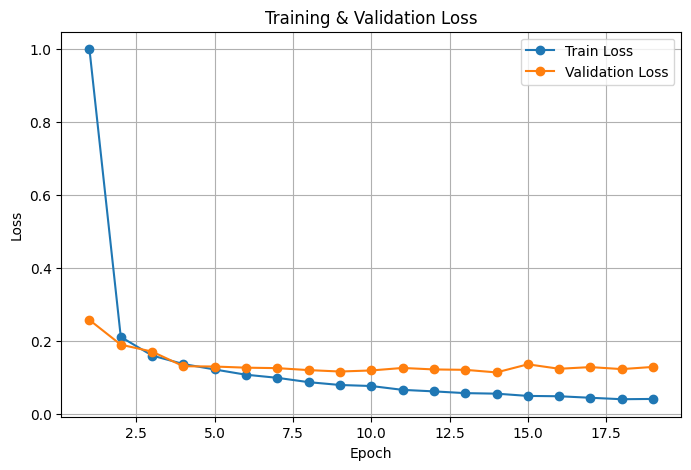

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Вход — слова + контекст
input_texts = [f"{w}" for w in df["word"].tolist()]
input_tokenizer = CharTokenizer(input_texts)

# Выход — аллофоны как списки
allophones_seqs = df["allophones"].tolist()
target_tokenizer = PhoneTokenizer(allophones_seqs)

train, val = train_test_split(df, test_size=0.3)

train_dataset = CustomDataset(train, input_tokenizer, target_tokenizer)
train_dataloader = DataLoader(train_dataset, batch_size=32, shuffle=True)

val_dataset = CustomDataset(val, input_tokenizer, target_tokenizer)
val_dataloader = DataLoader(val_dataset, batch_size=32, shuffle=True)

src_vocab_size = len(input_tokenizer.char2id)
tgt_vocab_size = len(target_tokenizer.id2phone)

model = Transformer(
    src_vocab_size, tgt_vocab_size,
    d_model=512, num_heads=8, num_layers=3,
    d_ff=128, max_seq_length=50,
    dropout=0.2, device=device
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss(ignore_index=input_tokenizer.char2id["<PAD>"])
early_stopping =  EarlyStopping(patience=5, delta=0.001, verbose=True)

train_model(model, train_dataloader,val_dataloader, optimizer, criterion, early_stopping, device, num_epochs=30)

torch.save(model, "model.pth")

In [66]:
# import random
# def param_search(d_model, num_heads,num_layers, d_ff, dropout):
#     model = Transformer(
#                         src_vocab_size,
#                         tgt_vocab_size,
#                         d_model=d_model,
#                         num_heads=num_heads,
#                         num_layers=num_layers,
#                         d_ff=d_ff,
#                         max_seq_length=50,
#                         dropout=dropout,
#                         device=device).to(device)
#     optimizer = optim.Adam(model.parameters(), lr=1e-4)
#     criterion = nn.CrossEntropyLoss(ignore_index=input_tokenizer.char2id["<PAD>"])
#     early_stopping =  EarlyStopping(patience=5, delta=0.001, verbose=True)
#     loss = train_model(model, train_dataloader,val_dataloader, optimizer, criterion, early_stopping, device, num_epochs=3, show_plot=False)

#     return loss

    
    
# param_grid = {"d_model": [128, 256, 512],
#               "num_heads": [2,4,8],
#               "num_layers": [3, 4, 5],
#               "d_ff": [128, 256, 512],
#               "dropout": [0.1, 0.2, 0.3]}
# n_search = 10

# result_dict = {}
# results = []
# best_loss = 0
# best_params = None
# for i in range(n_search):
#     # случайная выборка гиперпараметров
#     params = {k: random.choice(v) for k, v in param_grid.items()}
#     print(f"\n🔎 Запуск {i+1}/{n_search} с параметрами: {params}")
#     val_loss = param_search(**params)
#     results.append((params, val_loss))
#     print(f"✅ Validation loss = {val_loss:.4f}")
#     result_dict[f"✅ Validation loss = {val_loss:.4f}"] = val_loss
#     if val_loss < best_loss:
#         best_loss = val_loss
#         best_params = params


# print("\n🏁 Поиск завершён!")
# print(f"Лучший результат: loss = {best_loss:.4f}")
# print(f"Лучшие параметры: {best_params}")



In [1]:
# sorted_res = sorted(result_dict.items(), key=lambda item: item[1], reverse=True)


In [68]:
def greedy_decode(model, input_text, input_tokenizer, target_tokenizer, max_len=50, device="cpu"):
    model.eval()
    
    # Токенизация входа
    src_ids = torch.tensor(input_tokenizer.encode(input_text, max_length=max_len)).unsqueeze(0).to(device)  # (1, seq_len)
    
    # <BOS> для выхода
    generated = torch.tensor([target_tokenizer.phone2id["<BOS>"]], device=device).unsqueeze(0)  # (1,1)
    
    with torch.no_grad():
        for _ in range(max_len):
            # Предсказание
            output = model(src_ids, generated)  # (1, seq_len, vocab_size)
            next_token_logits = output[0, -1, :]  # логиты последнего токена
            next_token_id = next_token_logits.argmax().item()
            
            if next_token_id == target_tokenizer.phone2id["<EOS>"]:
                break
            
            # Добавляем токен к последовательности
            generated = torch.cat([generated, torch.tensor([[next_token_id]], device=device)], dim=1)
    
    # Декодируем в список аллофонов
    pred_phones = target_tokenizer.decode(generated[0].tolist())
    return pred_phones


In [69]:
loaded_model = torch.load('/kaggle/working/model.pth', weights_only=False) 
sample = df.iloc[3]
input_text = f"{sample['word']} | prev={sample['previous_word']} | next={sample['next_word']}"
predicted_phones = greedy_decode(model, input_text, input_tokenizer, target_tokenizer, device=device)

print("Слово:", sample['word'])
print("Реальные аллофоны:", sample['allophones'])
print("Предсказанные аллофоны:", predicted_phones)


Слово: холодное
Реальные аллофоны: ['h', 'a1', 'l', 'o0', 'd', 'n', 'a4', 'j', 'i4']
Предсказанные аллофоны: ['h', 'a1', 'l', 'o0', 'd', 'n', 'a4', 'j', 'i4']


In [70]:

metrics = test_model(
    model,
    val_dataloader,
    criterion,
    device,
    input_tokenizer,
    target_tokenizer,
    n_samples=5 # выводит ошибочные примеры
)

print(f"Eval Loss: {metrics['loss']:.4f}")
print(f"Token Accuracy: {metrics['ph_accuracy']:.4f}")
print(f"Word Accuracy: {metrics['word_accuracy']:.4f}")
print(f"Average Levenshtein Distance: {metrics['levenshtein']:.4f}")
print(f"Precision: {metrics['precision']:.4f}, Recall: {metrics['recall']:.4f}, F1: {metrics['f1']:.4f}")




Evaluation:   2%|▏         | 8/331 [00:00<00:08, 38.43it/s]

Input: опять | pre=и | next=-
Target: ['a1', "p'", 'a0', "t'"]
Predicted: ['a1', "p'", 'a0', "d'"]
----------------------------------------
Input: с | pre=нему | next=-
Target: ['s']
Predicted: ["s'"]
----------------------------------------
Input: несущегося | pre=жадно | next=в
Target: ["n'", 'i1', 's', 'u0', 'sc', 'i4', 'v', 'a4', "s'", 'a4']
Predicted: ["n'", 'i1', 's', 'u0', 'sc', 'i4', 'g', 'a4', "s'", 'a4']
----------------------------------------
Input: распростертыми | pre=с | next=-
Target: ['r', 'a2', 's', 'p', 'r', 'a1', "s'", "t'", 'o0', 'r', 't', 'y4', "m'", 'i4']
Predicted: ['r', 'a2', 's', 'p', 'r', 'a1', "s'", "t'", 'e0', 'r', 't', 'y4', "m'", 'i4']
----------------------------------------
Input: едете? -- | pre=-- Уж | next=-
Target: ['j', 'e0', "d'", 'i4', "t'", 'i4']
Predicted: ['j', 'i1', "d'", 'i4', "t'", 'i4']
----------------------------------------


Evaluation: 100%|██████████| 331/331 [00:06<00:00, 52.17it/s]


Eval Loss: 0.1298
Token Accuracy: 0.9548
Word Accuracy: 0.8190
Average Levenshtein Distance: 0.5736
Precision: 0.9381, Recall: 0.9548, F1: 0.9464


## Инференс

In [71]:
try:
    data = parse_xml(path)
except ET.ParseError as e:
    print(f"XML Parse Error: {e}")
    print("Please check the XML file for structural issues.")
    data = None

In [72]:
df = pd.DataFrame(get_features(data))
df.head()
df = df.fillna('-')[:10]

In [85]:
loaded_model = torch.load('/kaggle/working/model.pth', weights_only=False)
words_list = []


for i, (idx, row) in enumerate(df.iterrows()):
    input_text = f"{df.loc[idx, 'word']} | prev={df.loc[idx,'previous_word']} | next={df.loc[idx,'next_word']}"
    word_info = {
        "content": df.loc[idx, "word"],               # само слово
        "allophones": greedy_decode(loaded_model, input_text, input_tokenizer, target_tokenizer, device=device)
    }
    words_list.append(word_info)

# формируем итоговый словарь
result_json = {"words": words_list}

print(words_list[:10])
# сохраняем в файл
with open("predictions.json", "w", encoding="utf-8") as f:
    json.dump(result_json, f, ensure_ascii=False, indent=2)

ТЕМНЫЕ | prev=- | next=АЛЛЕИ
АЛЛЕИ | prev=ТЕМНЫЕ | next=-
В | prev=- | next=холодное
холодное | prev=В | next=осеннее
осеннее | prev=холодное | next=-
ненастье, | prev=осеннее | next=-
на | prev=- | next=одной
одной | prev=на | next=из
из | prev=одной | next=больших
больших | prev=из | next=-
[{'content': 'ТЕМНЫЕ', 'allophones': ["t'", 'o0', 'm', 'n', 'y4', 'j', 'i4']}, {'content': 'АЛЛЕИ', 'allophones': ['a0', 'l', 'a4', 'j', 'i4']}, {'content': 'В', 'allophones': ['v']}, {'content': 'холодное', 'allophones': ['h', 'a1', 'l', 'o0', 'd', 'n', 'a4', 'j', 'i4']}, {'content': 'осеннее', 'allophones': ['a1', "s'", 'e0', "n'", 'i4', 'j', 'i4']}, {'content': 'ненастье,', 'allophones': ["n'", 'e0', 'n', 'a4', "s'", "t'", 'j', 'i4']}, {'content': 'на', 'allophones': ['n', 'a2']}, {'content': 'одной', 'allophones': ['a1', 'd', 'n', 'o0', 'j']}, {'content': 'из', 'allophones': ['i1', 'z']}, {'content': 'больших', 'allophones': ['b', 'a1', "l'", 'sh', 'y0', 'h']}]
